<H1> Recomendation Systems </H1>

<hr>
Problem Statement -
Build your own recommendation system for products on an e-commerce website like Amazon.com.

Dataset -  Amazon Reviews data (http://jmcauley.ucsd.edu/data/amazon/) -  ratings_Electronics.csv 
Dataset columns - first three columns are userId, productId, and ratings and the fourth column is timestamp. You can discard the timestamp column as in this case you may not need to use it.
Steps -
1. Read and explore the dataset. (Rename column, plot histograms, find data characteristics)
2. Take subset of dataset to make it less sparse/more dense. (For example, keep the users only who has given 50 or more number of ratings )
3. Split the data randomly into train and test dataset. (For example split it in 70/30 ratio)
4. Build Popularity Recommender model.
5. Build Collaborative Filtering model.
6. Evaluate both the models. (Once the model is trained on the training data, it can be used to compute the error (RMSE) on predictions made on the test data.)
7. Get top - K (K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits,we will recommend 5 new products.
8. Summarise your insights.
<hr>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
column_names = ['userId','productId','ratings','timeStamp']
ratings_data = pd.read_csv('ratings_Electronics.csv',names=column_names)

In [4]:
#Droping the time stamp column
ratings_data.drop('timeStamp',axis=1,inplace=True)

In [5]:
ratings_data.head()

,userId,productId,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [6]:
ratings_data.shape

(7824482, 3)

In [7]:
ratings_data.dtypes

userId        object
productId     object
ratings      float64
dtype: object

In [8]:
#checking unique ratings
np.unique(ratings_data['ratings'])

array([1., 2., 3., 4., 5.])

In [9]:
#checking the total number or unique users
len(np.unique(ratings_data['productId']))

476002

In [10]:
#checking the total number or unique users
len(np.unique(ratings_data['userId']))

4201696

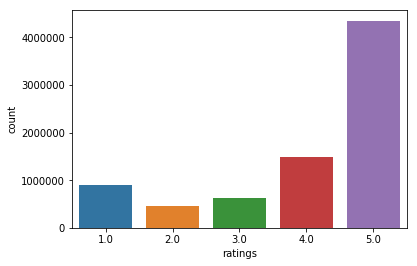

In [11]:
#Checking the distribution of the ratings
sns.countplot(ratings_data['ratings'])

In [12]:
#checking how sparse the matrix is - ie checking the no of ratings by each person
user_rating_count = ratings_data.groupby('userId').count()

In [13]:
user_rating_count[user_rating_count['ratings']>=50].count()

productId    1540
ratings      1540
dtype: int64

In [14]:
user_rating_count.reset_index(inplace=True)

In [15]:
users_over50 = user_rating_count[user_rating_count['ratings']>=50]['userId']

In [16]:
ratings_data.set_index('userId',inplace=True)

In [17]:
ratings_data_50plus = ratings_data.loc[users_over50]

In [18]:
ratings_data_50plus.reset_index(inplace=True)

In [19]:
ratings_data_50plus.shape

(125871, 3)

In [20]:
ratings_data_50plus.head()

,userId,productId,ratings
0,A100UD67AHFODS,B00004Z5M1,5.0
1,A100UD67AHFODS,B00005T3X7,5.0
2,A100UD67AHFODS,B000069EUW,5.0
3,A100UD67AHFODS,B000069JWX,1.0
4,A100UD67AHFODS,B0000AR0I4,5.0


<hr>
<h4> Some Observations on the users, products and the total dataset </h4>
<ul>
    <li>We have a total of 7,824,482 rows of data </li>
    <li>4,201,696 unique users </li>
    <li>476,002 unique products </li>  
    <li>A vast Majority of the ratings are good ratings 4,5</li>
    <li>Only 1540 of the total users have rated 50 or more items items</li>
    <li>For users who have rated 50 or above we have 125,871 rows of data</li>
</ul>
<hr>
  


## Popularity Based Recomender

### This is a very simpler recomender that does not take into account the user characteristics or community knowledge, it simply takes the most popular items and recomends them to the user.

In [21]:
product_ratings = ratings_data_50plus.groupby('productId').sum()

In [22]:
product_ratings.reset_index(inplace=True)

In [23]:
#Printing out the 10 most popular items in the entire list.
product_ratings.sort_values(by='ratings',ascending=False).head(10)

,productId,ratings
24827,B003ES5ZUU,895.0
39003,B0088CJT4U,869.0
11078,B000N99BBC,797.0
38250,B007WTAJTO,771.0
38615,B00829TIEK,661.0
38611,B00829THK0,605.0
39338,B008DWCRQW,561.0
28761,B004CLYEDC,551.0
21982,B002R5AM7C,528.0
22460,B002V88HFE,498.0



### In the popularity based recomender there is no personalisation based on users. We simply find the 10 most popular items and recommend it to all the users. 


## Collaborative Filtering Using Surprise

### There are two types of collaborative filtering methods: User to User, Item to Item 
### Further in in memory systems and model based systems
### Memory based systems will just use a similarity measure like cosine similarity to find the most similar users.


In [24]:
from surprise import KNNWithMeans
from surprise import SVD
from surprise import accuracy
from surprise import Reader
from surprise import Dataset
from surprise import NormalPredictor
from surprise.model_selection import cross_validate
from surprise.model_selection import train_test_split
from surprise.model_selection import KFold

<h3> Reading data into the Suprise Format </h3>

In [25]:
#Reading Data from the dataframe into a surprise format
reader = Reader(rating_scale=(1, 5))
# The columns must correspond to user id, product id and ratings.
data = Dataset.load_from_df(ratings_data_50plus[['userId', 'productId', 'ratings']], reader)


## User to User Collaborative Filtering


In [26]:
from __future__ import (absolute_import, division, print_function,
                        unicode_literals)

# Split into train and Split
trainset, testset = train_test_split(data, test_size=.30)

# Use user_based true/false to switch between user-based or item-based collaborative filtering
algo = KNNWithMeans(k=50, sim_options={'name': 'pearson_baseline', 'user_based': True})
algo.fit(trainset)

# run the trained model against the testset
test_pred = algo.test(testset)

# get RMSE
print("User-based Model : Test Set")
accuracy.rmse(test_pred, verbose=True)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
User-based Model : Test Set
RMSE: 1.0526


1.0525771591741346

In [27]:
from collections import defaultdict

from surprise import SVD
from surprise import Dataset


def get_top_n(predictions, n=10):
    '''Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    '''

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

## Top 5 Predictions for 10 users in the test dataset using user to user CF

In [28]:
top_n = get_top_n(test_pred,5)
# Print the recommended items for each user
cntrl = 0
print('Top 5 Predictions for some of the users are .....\n')
for uid, user_ratings in top_n.items():
    print(uid, [iid for (iid, _) in user_ratings])
    cntrl = cntrl+1
    if(cntrl==10):
        break

Top 5 Predictions for some of the users are .....

AT6CZDCP4TRGA ['B0000C20V3', 'B00004Y3V0', 'B00008Y1A4', 'B0009KIQNO', 'B0000C20T5']
A1ZU55TM45Y2R8 ['B003XIJ3MW', 'B001212ELY', 'B003ZTKFEE', 'B0054JE706', 'B00IVPU5BK']
A2X78O6G89CB30 ['B001EPVOQY', 'B0040JHVC2', 'B004J3V90Y', 'B000KZ70JE', 'B003924UBG']
A14I1F2H7NOYDC ['B000K50HJE', 'B000BQ7GW8', 'B000VKCIJU', 'B005LDLP8W', 'B0027VT6V4']
A100WO06OQR8BQ ['B0009YJXMS', 'B005A0B7CA', 'B0096LZ5QI', 'B0002L5R78', 'B00AYT62HC']
ACH055GTTIGC9 ['B003UE52ME', 'B0002VO8GE', 'B001DJHEVU', 'B0001HA8WW', 'B0011ZCDKS']
A2QRXQPHDMFCQV ['B0046A9RA4', 'B001NJE0LW', 'B003B47BZO', 'B003K0DC7K', 'B0044DEDB6']
A2XCCN239AR1XK ['B00CHH0JF0', 'B00F3F0EIU', 'B00IVFDZBC', 'B008LTBITY', 'B008R6WUZC']
A25WJCAP606YMP ['B00AXX0LQW', 'B00180LGX6', 'B006ZT4VA0', 'B000LY8DBS', 'B00099XXV0']
A10ZFE6YE0UHW8 ['B004FLL5AE', 'B00GJYJFKM', 'B00H7F9IVI', 'B00IX2VGFA', 'B0082E9K7U']



## Item to Item Collaborative Filtering 
### This model will take 5-10 minutes to run 


In [29]:
trainset, testset = train_test_split(data, test_size=.30)
print('This model will take 5-10 minutes to run please wait...')
# Use user_based true/false to switch between user-based or item-based collaborative filtering
algo = KNNWithMeans(k=50, sim_options={'name': 'pearson_baseline', 'user_based': False})
algo.fit(trainset)

# run the trained model against the testset
test_pred = algo.test(testset)

# get RMSE
print("Item-based Model : Test Set")
accuracy.rmse(test_pred, verbose=True)

# if you wanted to evaluate on the trainset
print("Item-based Model : Training Set")
train_pred = algo.test(trainset.build_testset())
accuracy.rmse(train_pred)

This model will take 5-10 minutes to run please wait...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Item-based Model : Test Set
RMSE: 1.1447
Item-based Model : Training Set
RMSE: 0.0179


0.017876671279434517

## Top 5 Predictions for 10 users in the test dataset using item to item CF

In [30]:
top_n = get_top_n(test_pred,5)
# Print the recommended items for each user
cntrl = 0
print('Top 5 Predictions for some of the users are .....\n')
for uid, user_ratings in top_n.items():
    print(uid, [iid for (iid, _) in user_ratings])
    cntrl = cntrl+1
    if(cntrl==10):
        break

Top 5 Predictions for some of the users are .....

A2UOHALGF2X77Q ['B007JY58FM', 'B005DIQ2OC', 'B009KUT30E', 'B000V0BXLE', 'B002OJN250']
A1IDAKX7OM3QIE ['B00DVPGBDG', 'B000N99BBC', 'B00829TIEK', 'B00G5RDU5O', 'B000X38ZO2']
ADOR3TR7GDF68 ['B005CTCD6S', 'B00768SBAU', 'B003765X38', 'B005FYNSPK', 'B0018MCGVU']
A2WC9NFLG57W4H ['B002PU9SQU', 'B002TOJXIA', 'B001TOD7N8', 'B00EOE4G4E', 'B0058GK55Q']
A1AH8033GWKBY7 ['B004H9C4JK', 'B00FNPD1VW', 'B004E5W35W', 'B003LVZO88', 'B000BTL0OA']
A3S0DBBR693O06 ['B009NQLT0M', 'B00EUFP39E', 'B0000A2QBP', 'B00406YHLI', 'B007JIBAZA']
AULFLNWJP1QXY ['B004CLYEBY', 'B0008102WM', 'B000M9MKES', 'B0000XMV86', 'B00006HOA1']
A19X4BF861LQST ['B00004ZCA5', 'B00005Q5ZC', 'B0083U94D8', 'B00009R86Q', 'B0050QJUP0']
A1WUQF5HWBAQJU ['B00EY3YGBS', 'B00HVMIL1U', 'B009SGB3KI', 'B003TUMDWG', 'B008RM235I']
A34JKODTSKCGEN ['B001BAWU5Q', 'B000TTMJ2E', 'B000JSFZPS', 'B002BH3UA2', 'B00CTY84KI']


## Model Based (SVD) Collaborative Filtering


In [31]:
from surprise import SVDpp
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split
from surprise.model_selection import GridSearchCV
from surprise.model_selection import cross_validate
import datetime

print(datetime.datetime.now())

#param_grid = {'n_factors': [110, 120, 140, 160], 'n_epochs': [100], 'lr_all': [0.001, 0.003, 0.005, 0.008],
#              'reg_all': [0.08, 0.1, 0.15]}

#gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3,joblib_verbose=5,n_jobs=-2)
#gs.fit(data)
#algo = gs.best_estimator['rmse']
#print(gs.best_score['rmse'])
#print(gs.best_params['rmse'])
#cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


# train test split
trainset, testset = train_test_split(data, test_size=.30)

#SVD Model
#algo = SVD(n_factors=160, n_epochs=100, lr_all=0.005, reg_all=0.1,verbose=True)
algo = SVD(n_epochs=100, lr_all=0.05, verbose=True)
algo.fit(trainset)
test_pred = algo.test(testset)
print("SVD : Test Set")
accuracy.rmse(test_pred, verbose=True)

print(datetime.datetime.now())

2019-03-18 21:34:21.850385
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Pro

## Top 5 Predictions for 10 users in the test dataset using SVD

In [32]:
top_n = get_top_n(test_pred,5)
# Print the recommended items for each user
cntrl = 0
print('Top 5 Predictions for some of the users are .....\n')
for uid, user_ratings in top_n.items():
    print(uid, [iid for (iid, _) in user_ratings])
    cntrl = cntrl+1
    if(cntrl==10):
        break

Top 5 Predictions for some of the users are .....

A3P69DTOXII004 ['B00CRXZPA8', 'B0007Y79AI', 'B00H0JPSMY', 'B00HRO32O8', 'B00J0TQ86C']
A3NGOG8Z78AZSD ['B004ELA0SS', 'B004SCSV2U', 'B003O8682Y', 'B002J9HBSE', 'B004LUY65U']
A1ODOGXEYECQQ8 ['B001TUYTZM', 'B000VX6XL6', 'B0082E9K7U', 'B005E8MVV4', 'B0011ZCDKS']
A3T8WOFS5RD2IR ['B0008D76L0', 'B0000C4G78', 'B00009R896', 'B000WOIFO2', 'B00017LSPI']
A1OES7R7FDAT2L ['B001QUA6RA', 'B000FQ2JLW', 'B001MSU1FS', 'B0006U3ACY', 'B0000AZK0D']
A4S2WAQVQR6PI ['B0027AGK3M', 'B005CWIVYI', 'B002TA7VO2', 'B002RCNX8K', 'B004LXJXSW']
A1RPJHUVVSI98A ['B0009M1O9A', 'B002PAX9QU', 'B00005LE7M', 'B000JE7GPY', 'B000M3ILF6']
A250AXLRBVYKB4 ['B0019EHU8G', 'B001UI2FPE', 'B0009JZSKO', 'B001IEZX3G', 'B002DN928S']
A31HOWJKEIY037 ['B0036V9AGU', 'B005F778JO', 'B0097BEFYA', 'B001E1Y5O6', 'B003M0NURK']
A1S27P7KJO9I96 ['B0062XB9FE', 'B00DR8LA60', 'B000V01RLK', 'B001BM5XB2', 'B00D429Y12']


## Summary / Observations

### Popularity based recommender is a plain vanilla system that looks at the most popular items across the entire dataset
### Popularity besed systems are limited in its application, since it does not take into account the power of the community or personalise the recomendations to a user
### User to User colloborative filtering uses the power of the community. It first tries to find similar users using cosine similarity or pearson correlation. Having found simular users, it calculates a weighted average of the ratings for a particular item from the cohort of similar users. This makes the prediction far more accurate, as seen from the RMSE value
### Item to item is by far the best way to do it since it avoids the problem of cold start and also it produces more homogenous groups, compared to the user to user model. This initution is borne out by the RMSE numbers, which are better than that of the user to user model
### Ideally the model based system should yield better results, but in this case the model's hyper parameters need optimisation. This is not done because it takes way too long to run on a laptop.